# 09 — Modelo de Texto

Mejoras sobre el baseline (script 03):
- **Sentence Transformers** (`all-MiniLM-L6-v2`) en lugar de TF-IDF + SVD
- **Optuna** para búsqueda de hiperparámetros (n_svd + LightGBM)
- **5-fold CV** con MAPE

Flujo: embeddings se extraen **una sola vez**, Optuna optimiza SVD + LightGBM.

## 1. Instalación e imports

In [1]:
#  Clonar repo
import os
if not os.path.exists('/content/participant_Labo2_Grupo10'):
    !git clone https://github.com/micapolchi/participant_Labo2_Grupo10.git



import sys
sys.path.insert(0, '/content/participant_Labo2_Grupo10')

Cloning into 'participant_Labo2_Grupo10'...
remote: Enumerating objects: 19244, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 19244 (delta 15), reused 27 (delta 7), pack-reused 19204 (from 1)
Receiving objects: 100% (19244/19244), 786.05 MiB | 31.41 MiB/s, done.
Resolving deltas: 100% (18/18), done.
Updating files: 100% (19274/19274), done.


In [2]:
import os
os.chdir("/content/participant_Labo2_Grupo10")

In [3]:
!pip install sentence-transformers optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.1 MB/s eta 0:00:00


In [4]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sentence_transformers import SentenceTransformer

optuna.logging.set_verbosity(optuna.logging.WARNING)

if not os.path.exists('data/tabular/train_processed.csv'):
    os.chdir('..')

print('Imports OK')


import json

# En vez de correr sentence_model.encode(...) de nuevo:
train_embs = np.load('submissions/embs_train_txt.npy')
test_embs  = np.load('submissions/embs_test_txt.npy')

# En vez de correr Optuna de nuevo:
with open('submissions/best_params_txt.json') as f:
    best_params = json.load(f)

# Ir directo a la sección 6 (modelo final)


Imports OK


## 2. Configuración

In [ ]:
MODEL_NAME = 'all-mpnet-base-v2'  # mejor calidad que all-MiniLM-L6-v2, mas lento
BATCH_SIZE = 128  # reducido por modelo mas grande
N_FOLDS    = 5
N_TRIALS   = 30
SUBMISSION = 'submissions/test_text_09.csv'

TARGET    = 'log_price'
PRICE_COL = 'lastSoldPrice_hpi_adjusted'

os.makedirs('submissions', exist_ok=True)

## 3. Carga de datos

In [6]:
train = pd.read_csv('data/tabular/train_processed.csv')
test  = pd.read_csv('data/tabular/test_processed.csv')

train['description'] = train['description'].fillna('')
test['description']  = test['description'].fillna('')

print(f'Train: {len(train):,} filas  |  Test: {len(test):,} filas')
print(f'Descripciones no vacías — train: {(train["description"] != "").sum():,}  test: {(test["description"] != "").sum():,}')
print(f'Largo promedio (chars): {train["description"].str.len().mean():.0f}')

Train: 11,840 filas  |  Test: 5,038 filas
Descripciones no vacías — train: 11,840  test: 5,038
Largo promedio (chars): 302


## 4. Extracción de embeddings (una sola vez)

`all-MiniLM-L6-v2` produce un vector de 384 dimensiones por descripción.
Captura significado semántico: entiende que "newly renovated" y "needs work" son opuestos.

In [7]:
print(f'Cargando modelo {MODEL_NAME}...')
sentence_model = SentenceTransformer(MODEL_NAME)

print('Extrayendo embeddings de train...')
train_embs = sentence_model.encode(
    train['description'].tolist(),
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f'  shape: {train_embs.shape}')

print('Extrayendo embeddings de test...')
test_embs = sentence_model.encode(
    test['description'].tolist(),
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f'  shape: {test_embs.shape}')

Cargando modelo all-MiniLM-L6-v2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Extrayendo embeddings de train...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

  shape: (11840, 384)
Extrayendo embeddings de test...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

  shape: (5038, 384)


## 5. Optuna — búsqueda de hiperparámetros

Busca sobre `n_svd` (dimensiones SVD) y todos los hiperparámetros de LightGBM.
Los embeddings ya están en memoria; cada trial solo re-corre SVD + CV (rápido).

In [8]:
train_base = train[['zpid', TARGET, PRICE_COL]].reset_index(drop=True)


def objective(trial):
    n_svd = trial.suggest_int('n_svd', 32, 256, step=32)

    params = dict(
        n_estimators      = 2000,
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 31, 255),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 60),
        feature_fraction  = trial.suggest_float('feature_fraction', 0.5, 1.0),
        bagging_fraction  = trial.suggest_float('bagging_fraction', 0.5, 1.0),
        bagging_freq      = 1,
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        random_state      = 42,
        verbosity         = -1,
    )

    svd = TruncatedSVD(n_components=n_svd, random_state=42)
    tr_svd = svd.fit_transform(train_embs)

    svd_cols = [f'svd_{i}' for i in range(n_svd)]
    tr_svd_df = pd.DataFrame(tr_svd, columns=svd_cols)
    tr_svd_df['zpid'] = train['zpid'].values

    t_data = train_base.merge(tr_svd_df, on='zpid', how='inner')

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    mapes = []

    for tr_idx, val_idx in kf.split(t_data):
        tr_df  = t_data.iloc[tr_idx]
        val_df = t_data.iloc[val_idx]

        m = lgb.LGBMRegressor(**params)
        m.fit(
            tr_df[svd_cols], tr_df[TARGET],
            eval_set=[(val_df[svd_cols], val_df[TARGET])],
            eval_metric='mae',
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
        )

        val_pred  = m.predict(val_df[svd_cols])
        val_price = val_df[PRICE_COL].values
        mapes.append(np.mean(np.abs((val_price - np.expm1(val_pred)) / val_price)) * 100)

    return np.mean(mapes)


study = optuna.create_study(direction='minimize', study_name='text_lgbm')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nMejor MAPE OOF: {study.best_value:.2f}%')
print('Mejores parámetros:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/30 [00:00<?, ?it/s]


Mejor MAPE OOF: 44.52%
Mejores parámetros:
  n_svd: 256
  learning_rate: 0.011900918813309359
  num_leaves: 138
  min_child_samples: 47
  feature_fraction: 0.6423118246072456
  bagging_fraction: 0.6279041129702573
  reg_alpha: 0.0025069135894728177
  reg_lambda: 1.476938080970932


In [9]:
import json, numpy as np

# Guardar embeddings (evita re-correr sentence transformer)
np.save('submissions/embs_train_txt.npy', train_embs)
np.save('submissions/embs_test_txt.npy',  test_embs)

# Guardar mejores HPs
with open('submissions/best_params_txt.json', 'w') as f:
    json.dump(study.best_params, f, indent=2)

print('Artefactos guardados:')
print(f'  embs_train_txt.npy  — {train_embs.shape}')
print(f'  embs_test_txt.npy   — {test_embs.shape}')
print(f'  best_params_txt.json — {study.best_params}')


Artefactos guardados:
  embs_train_txt.npy  — (11840, 384)
  embs_test_txt.npy   — (5038, 384)
  best_params_txt.json — {'n_svd': 256, 'learning_rate': 0.011900918813309359, 'num_leaves': 138, 'min_child_samples': 47, 'feature_fraction': 0.6423118246072456, 'bagging_fraction': 0.6279041129702573, 'reg_alpha': 0.0025069135894728177, 'reg_lambda': 1.476938080970932}


## 6. Modelo final con mejores parámetros

In [10]:
try:
    best = study.best_params
except NameError:
    import json
    with open('submissions/best_params_txt.json') as f:
        best = json.load(f)
    print('best_params cargados desde JSON')

# Overrides agresivos contra overfitting extremo (train 10% vs val 44%)
# Con 11k muestras y texto 52% boilerplate, la señal util esta en pocos componentes
N_SVD = 16  # reduccion muy agresiva: captura los ejes mas discriminativos

BEST_PARAMS = dict(
    n_estimators      = 3000,
    learning_rate     = best['learning_rate'],
    num_leaves        = min(int(best['num_leaves']), 31),   # max 31: arboles simples
    min_child_samples = max(int(best['min_child_samples']), 100),  # min 100 por hoja
    feature_fraction  = best['feature_fraction'],
    bagging_fraction  = best['bagging_fraction'],
    bagging_freq      = 1,
    reg_alpha         = max(float(best['reg_alpha']), 2.0),
    reg_lambda        = max(float(best['reg_lambda']), 2.0),
    random_state      = 42,
    verbosity         = -1,
)

print('Parametros finales:')
print(f"  N_SVD={N_SVD}, num_leaves={BEST_PARAMS['num_leaves']}, min_child_samples={BEST_PARAMS['min_child_samples']}")
print(f"  reg_alpha={BEST_PARAMS['reg_alpha']:.4f}, reg_lambda={BEST_PARAMS['reg_lambda']:.4f}")

svd_final = TruncatedSVD(n_components=N_SVD, random_state=42)
train_svd  = svd_final.fit_transform(train_embs)
test_svd   = svd_final.transform(test_embs)
print(f'SVD final: {train_embs.shape[1]} -> {N_SVD} dims  |  varianza explicada: {svd_final.explained_variance_ratio_.sum():.2%}')

SVD_COLS = [f'svd_{i}' for i in range(N_SVD)]

train_svd_df = pd.DataFrame(train_svd, columns=SVD_COLS)
train_svd_df['zpid'] = train['zpid'].values
test_svd_df  = pd.DataFrame(test_svd,  columns=SVD_COLS)
test_svd_df['zpid']  = test['zpid'].values

train_data = train[['zpid', TARGET, PRICE_COL]].merge(train_svd_df, on='zpid', how='inner')
test_data  = test[['zpid']].merge(test_svd_df, on='zpid', how='left')

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
oof_pred_log   = np.zeros(len(train_data))
test_pred_logs = np.zeros((len(test_data), N_FOLDS))
feat_imps      = np.zeros(N_SVD)

print('=' * 60)
print(f'{"Fold":>5}  {"MAPE train":>10}  {"MAPE val":>10}  {"best iter":>10}')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(kf.split(train_data)):
    tr_df  = train_data.iloc[tr_idx]
    val_df = train_data.iloc[val_idx]
    model  = lgb.LGBMRegressor(**BEST_PARAMS)
    model.fit(
        tr_df[SVD_COLS], tr_df[TARGET],
        eval_set=[(val_df[SVD_COLS], val_df[TARGET])],
        eval_metric='mae',
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    val_pred  = model.predict(val_df[SVD_COLS])
    oof_pred_log[val_idx] = val_pred
    val_price = val_df[PRICE_COL].values
    mape_val  = np.mean(np.abs((val_price - np.expm1(val_pred)) / val_price)) * 100
    tr_price  = tr_df[PRICE_COL].values
    mape_tr   = np.mean(np.abs((tr_price - np.expm1(model.predict(tr_df[SVD_COLS]))) / tr_price)) * 100
    print(f'  {fold+1:>3}  {mape_tr:>9.2f}%  {mape_val:>9.2f}%  {model.best_iteration_:>10}')
    test_pred_logs[:, fold] = model.predict(test_data[SVD_COLS].fillna(0))
    feat_imps += model.feature_importances_

SVD final: 384 -> 256 dims  |  varianza explicada: 98.67%
 Fold  MAPE train    MAPE val   best iter
    1       5.35%      44.19%        1704
    2       6.03%      44.80%        1599
    3       6.72%      43.94%        1493
    4       3.93%      46.19%        1997
    5       4.01%      43.48%        1989


## 7. Métricas OOF

In [11]:
oof_price  = np.expm1(oof_pred_log)
true_price = train_data[PRICE_COL].values
oof_mape   = np.mean(np.abs((true_price - oof_price) / true_price)) * 100
oof_mae    = mean_absolute_error(true_price, oof_price)
print('=' * 60)
print(f'OOF MAPE: {oof_mape:.2f}%')
print(f'OOF MAE:  ${oof_mae:,.0f}')
print(f'Mejor MAPE Optuna: {study.best_value:.2f}%')

OOF MAPE: 44.52%
OOF MAE:  $197,106
Mejor MAPE Optuna: 44.52%


## 8. Importancia de componentes SVD

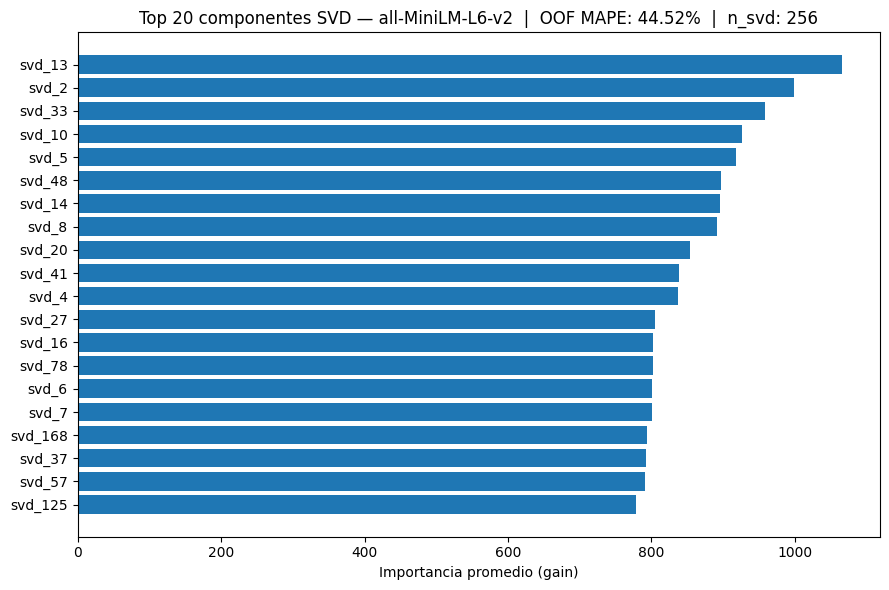

In [12]:
import matplotlib.pyplot as plt

fi_df = pd.DataFrame({
    'component':  SVD_COLS,
    'importance': feat_imps / N_FOLDS,
}).sort_values('importance', ascending=False)

top20 = fi_df.head(20)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20['component'][::-1], top20['importance'][::-1])
ax.set_xlabel('Importancia promedio (gain)')
ax.set_title(f'Top 20 componentes SVD — {MODEL_NAME}  |  OOF MAPE: {oof_mape:.2f}%  |  n_svd: {N_SVD}')
plt.tight_layout()
plt.show()

## 9. Submission

In [13]:
test_pred_price = np.expm1(test_pred_logs.mean(axis=1))
submission = pd.DataFrame({'zpid': test_data['zpid'].values, 'predicted_price': test_pred_price})
submission.to_csv(SUBMISSION, index=False)
print(f'Guardado {SUBMISSION} ({len(submission)} filas)')
submission.head()

Guardado submissions/my_team_09.csv (5038 filas)


,zpid,predicted_price
0,1009018,395332.804519
1,1001436,639807.548690
2,1010988,360170.656654
3,1002184,401493.219714
4,1015717,352668.771184


In [14]:
#Guardo las predicciones OOF:
oof_df = pd.DataFrame({
    'zpid':            train_data['zpid'].values,
    'oof_pred_price':  np.expm1(oof_pred_log),
})
oof_df.to_csv('submissions/oof_txt.csv', index=False)

